# Fleet Movement Analysis

Loads winner observation data from `11-download_logs/01-winner/`, builds `df_fleet` and `df_planets` per timestep, joins them on origin planet, then computes fleet speed, distance from origin planet, and step-over-step displacement.

In [3]:
import json
import math
import pandas as pd
import numpy as np
from pathlib import Path

ep_id = "76319029"

with open(f"11-download_logs/01-winner/episode-{ep_id}.json") as f:
    winner_data = json.load(f)

## Build df_fleet and df_planets

Fleet fields per step: `[id, owner, x, y, angle, from_planet_id, ships]`  
Planet fields per step: `[id, owner, x, y, radius, ships, production]`

In [4]:
fleet_rows = []
planet_rows = []

for obs in winner_data:
    step = obs["step"]

    for f in obs["fleets"]:
        fleet_rows.append({
            "step":           step-1,
            "id":             f[0],
            "owner":          f[1],
            "x":              f[2],
            "y":              f[3],
            "angle":          f[4],
            "from_planet_id": f[5],
            "ships":          f[6],
        })

    for p in obs["planets"]:
        planet_rows.append({
            "step":       step,
            "id":         p[0],
            "owner":      p[1],
            "x":          p[2],
            "y":          p[3],
            "radius":     p[4],
            "ships":      p[5],
            "production": p[6],
        })

df_fleet   = pd.DataFrame(fleet_rows).drop_duplicates(subset=["step", "id"]).reset_index(drop=True)
df_planets = pd.DataFrame(planet_rows).drop_duplicates(subset=["step", "id"]).reset_index(drop=True)

print(df_fleet.shape, df_planets.shape)
df_fleet

(1529, 8) (6364, 8)


,step,id,owner,x,y,angle,from_planet_id,ships
0,4,0,0,65.667698,92.864106,4.198040,4,18
1,4,1,1,34.957666,6.702306,0.872665,7,18
2,5,0,0,64.509946,90.815290,4.198040,4,18
3,5,1,1,36.470340,8.505041,0.872665,7,18
4,6,0,0,63.352195,88.766473,4.198040,4,18
...,...,...,...,...,...,...,...,...
1524,164,405,1,69.375049,21.907480,2.687807,34,38
1525,165,405,1,66.758961,23.183431,2.687807,34,38
1526,166,405,1,64.142872,24.459383,2.687807,34,38
1527,167,405,1,61.526784,25.735334,2.687807,34,38


## Join fleet with origin planet

Left-join `df_fleet` onto `df_planets` matching each fleet's `from_planet_id` to the planet `id` at the same step.

In [5]:
df = df_fleet.merge(
    df_planets,
    left_on=["step", "from_planet_id"],
    right_on=["step", "id"],
    how="left",
    suffixes=("_fleet", "_planet"),
)

# Rename the unambiguous fleet 'id' column (kept as id_fleet after merge)
df = df.rename(columns={"id_fleet": "id"})

print(df.shape)
df.head()

(1529, 15)


,step,id,owner_fleet,x_fleet,y_fleet,angle,from_planet_id,ships_fleet,id_planet,owner_planet,x_planet,y_planet,radius,ships_planet,production
0,4,0,0,65.667698,92.864106,4.198040,4,18,4.0,0.0,67.707621,96.47406,1.693147,18.0,2.0
1,4,1,1,34.957666,6.702306,0.872665,7,18,7.0,1.0,32.292379,3.52594,1.693147,18.0,2.0
2,5,0,0,64.509946,90.815290,4.198040,4,18,4.0,0.0,67.707621,96.47406,1.693147,2.0,2.0
3,5,1,1,36.470340,8.505041,0.872665,7,18,7.0,1.0,32.292379,3.52594,1.693147,2.0,2.0
4,6,0,0,63.352195,88.766473,4.198040,4,18,4.0,0.0,67.707621,96.47406,1.693147,4.0,2.0


## Derived metrics

In [6]:
MAX_SPEED = 6.0

def fleet_speed(nb_ships):
    if nb_ships <= 1:
        return 1.0
    ratio = math.log(nb_ships) / math.log(1000.0)
    return 1.0 + (MAX_SPEED - 1.0) * max(0.0, min(1.0, ratio)) ** 1.5

# Speed — vectorised via apply (ships_fleet col)
df["speed"] = df["ships_fleet"].apply(fleet_speed)

# Distance from origin planet surface at current step
df["dist_from_origin"] = np.sqrt(
    (df["x_planet"] - df["x_fleet"]) ** 2 +
    (df["y_planet"] - df["y_fleet"]) ** 2
)

# Step-over-step displacement per fleet id
df = df.sort_values(["id", "step"]).reset_index(drop=True)
df["x_prev"] = df.groupby("id")["x_fleet"].shift(1)
df["y_prev"] = df.groupby("id")["y_fleet"].shift(1)
df["dist_from_prev"] = np.sqrt(
    (df["x_prev"] - df["x_fleet"]) ** 2 +
    (df["y_prev"] - df["y_fleet"]) ** 2
)
df = df.drop(columns=["x_prev", "y_prev"])

df[["step", "id", "ships_fleet", "speed", "dist_from_origin", "dist_from_prev"]].head(20)

,step,id,ships_fleet,speed,dist_from_origin,dist_from_prev
0,4,0,18,2.353303,4.146450,NaN
1,5,0,18,2.353303,6.499754,2.353303
2,6,0,18,2.353303,8.853057,2.353303
3,7,0,18,2.353303,11.206360,2.353303
4,4,1,18,2.353303,4.146450,NaN
5,5,1,18,2.353303,6.499754,2.353303
6,6,1,18,2.353303,8.853057,2.353303
7,7,1,18,2.353303,11.206360,2.353303
8,10,2,12,2.078772,3.871919,NaN
9,11,2,12,2.078772,5.950691,2.078772


## Sanity check — fleet 32

Fleet 32 carries 70 ships; expected speed ≈ 3.41. `dist_from_prev` should match that speed.

In [7]:
df[df["id"] == 32][["step", "x_fleet", "y_fleet", "ships_fleet", "speed", "dist_from_origin", "dist_from_prev"]]

,step,x_fleet,y_fleet,ships_fleet,speed,dist_from_origin,dist_from_prev
180,41,92.951778,75.730670,70,3.411667,6.121105,NaN
181,42,94.549698,72.716351,70,3.411667,9.532771,3.411667
182,43,96.147619,69.702032,70,3.411667,12.944438,3.411667


# First appearance of fleet 

In [8]:
(
    df
    # .query("dist_from_prev.isna()")
    # .assign(
    #     dist_from_origin_radius=lambda d: d["dist_from_origin"] - d["radius"]
    # )
)

,step,id,owner_fleet,x_fleet,y_fleet,angle,from_planet_id,ships_fleet,id_planet,owner_planet,x_planet,y_planet,radius,ships_planet,production,speed,dist_from_origin,dist_from_prev
0,4,0,0,65.667698,92.864106,4.198040,4,18,4.0,0.0,67.707621,96.474060,1.693147,18.0,2.0,2.353303,4.146450,NaN
1,5,0,0,64.509946,90.815290,4.198040,4,18,4.0,0.0,67.707621,96.474060,1.693147,2.0,2.0,2.353303,6.499754,2.353303
2,6,0,0,63.352195,88.766473,4.198040,4,18,4.0,0.0,67.707621,96.474060,1.693147,4.0,2.0,2.353303,8.853057,2.353303
3,7,0,0,62.194444,86.717657,4.198040,4,18,4.0,0.0,67.707621,96.474060,1.693147,6.0,2.0,2.353303,11.206360,2.353303
4,4,1,1,34.957666,6.702306,0.872665,7,18,7.0,1.0,32.292379,3.525940,1.693147,18.0,2.0,2.353303,4.146450,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,159,411,1,93.200697,12.780617,1.815142,34,8,34.0,1.0,93.908517,9.941708,1.000000,8.0,1.0,1.825819,2.925819,NaN
1525,160,411,1,92.758992,14.552201,1.815142,34,8,34.0,0.0,93.908517,9.941708,1.000000,136.0,1.0,1.825819,4.751637,1.825819
1526,161,411,1,92.317286,16.323785,1.815142,34,8,34.0,0.0,93.908517,9.941708,1.000000,1.0,1.0,1.825819,6.577456,1.825819
1527,162,411,1,91.875581,18.095369,1.815142,34,8,34.0,0.0,93.908517,9.941708,1.000000,2.0,1.0,1.825819,8.403274,1.825819


## Explaining `dist_from_origin` at spawn (first appearance)

`dist_from_prev` is NaN on a fleet's first step — the spawn moment.
At spawn a fleet is placed on the **surface** of its origin planet, so:

```
dist_from_origin ≈ radius_planet
```

Speed doesn't influence where the fleet spawns, but we plot it too to rule out any correlation.

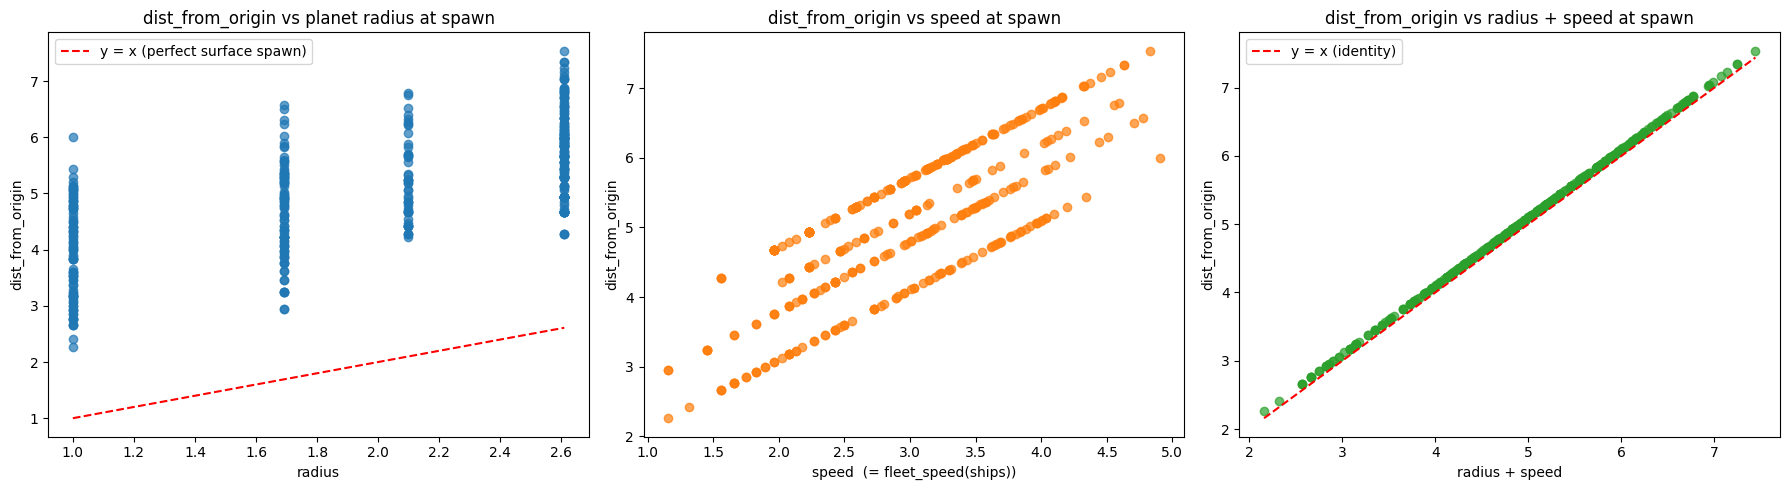

Residual dist_from_origin - radius:
count    390.000000
mean       3.072427
std        0.779914
min        1.258929
25%        2.453303
50%        3.108881
75%        3.604392
max        5.004642
dtype: float64


<Figure size 640x480 with 0 Axes>

Residual dist_from_origin - radius:
count    390.000000
mean       3.072427
std        0.779914
min        1.258929
25%        2.453303
50%        3.108881
75%        3.604392
max        5.004642
dtype: float64


In [9]:
import matplotlib.pyplot as plt

df_spawn = df.query("dist_from_prev.isna()").copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- dist_from_origin vs radius ---
ax = axes[0]
ax.scatter(df_spawn["radius"], df_spawn["dist_from_origin"], alpha=0.7)
r_min, r_max = df_spawn["radius"].min(), df_spawn["radius"].max()
ax.plot([r_min, r_max], [r_min, r_max], "r--", label="y = x (perfect surface spawn)")
ax.set_xlabel("radius")
ax.set_ylabel("dist_from_origin")
ax.set_title("dist_from_origin vs planet radius at spawn")
ax.legend()

# --- dist_from_origin vs speed ---
ax = axes[1]
ax.scatter(df_spawn["speed"], df_spawn["dist_from_origin"], alpha=0.7, color="tab:orange")
ax.set_xlabel("speed  (= fleet_speed(ships))")
ax.set_ylabel("dist_from_origin")
ax.set_title("dist_from_origin vs speed at spawn")

# --- dist_from_origin vs radius + speed ---
ax = axes[2]
x = df_spawn["radius"] + df_spawn["speed"]
ax.scatter(x, df_spawn["dist_from_origin"], alpha=0.7, color="tab:green")
x_min, x_max = x.min(), x.max()
ax.plot([x_min, x_max], [x_min, x_max], "r--", label="y = x (identity)")
ax.set_xlabel("radius + speed")
ax.set_ylabel("dist_from_origin")
ax.set_title("dist_from_origin vs radius + speed at spawn")
ax.legend()

plt.tight_layout()
plt.show()

print("Residual dist_from_origin - radius:")
print((df_spawn["dist_from_origin"] - df_spawn["radius"]).describe())
r_min, r_max = df_spawn["radius"].min(), df_spawn["radius"].max()
ax.plot([r_min, r_max], [r_min, r_max], "r--", label="y = x (perfect surface spawn)")
ax.set_xlabel("radius")
ax.set_ylabel("dist_from_origin")
ax.set_title("dist_from_origin vs planet radius at spawn")
ax.legend()

# --- dist_from_origin vs speed ---
ax = axes[1]
ax.scatter(df_spawn["speed"], df_spawn["dist_from_origin"], alpha=0.7, color="tab:orange")
ax.set_xlabel("speed  (= fleet_speed(ships))")
ax.set_ylabel("dist_from_origin")
ax.set_title("dist_from_origin vs speed at spawn")

plt.tight_layout()
plt.show()

print("Residual dist_from_origin - radius:")
print((df_spawn["dist_from_origin"] - df_spawn["radius"]).describe())

In [10]:
import plotly.express as px

df_spawn = df.query("dist_from_prev.isna()").copy()
df_spawn["radius_plus_speed"] = df_spawn["radius"] + df_spawn["speed"]

fig = px.scatter(
    df_spawn,
    x="radius_plus_speed",
    y="dist_from_origin",
    hover_data=["step", "id", "ships_fleet", "speed"],
    labels={
        "radius_plus_speed": "radius + speed",
        "dist_from_origin": "dist_from_origin",
    },
    title="dist_from_origin vs radius + speed at spawn",
    opacity=0.7,
)

min_val = df_spawn["radius_plus_speed"].min()
max_val = df_spawn["radius_plus_speed"].max()

fig.add_shape(
    type="line",
    x0=min_val,
    x1=max_val,
    y0=min_val,
    y1=max_val,
    line=dict(color="red", dash="dash"),
)

fig.update_layout(
    xaxis=dict(range=[min_val, max_val]),
    yaxis=dict(range=[min_val, max_val]),
)

fig.show()

In [11]:
import statsmodels.api as sm

exclude = {"dist_from_origin", "id_planet"}
X_cols = [c for c in df_spawn.select_dtypes("number").columns if c not in exclude]
X_cols = ["radius", "speed"]  # for better interpretability

data = (
    df_spawn[X_cols + ["dist_from_origin"]]
    # .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
print(f"Rows kept: {len(data)} / {len(df_spawn)}  (dropped {len(df_spawn) - len(data)})")
print(f"Columns: {X_cols}\n")

X = data[X_cols]
y = data["dist_from_origin"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

Rows kept: 390 / 390  (dropped 0)
Columns: ['radius', 'speed']

                            OLS Regression Results                            
Dep. Variable:       dist_from_origin   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.451e+30
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        17:58:43   Log-Likelihood:                 12305.
No. Observations:                 390   AIC:                        -2.460e+04
Df Residuals:                     387   BIC:                        -2.459e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [12]:
(
    df_spawn
    [X_cols + ["dist_from_origin"]]
    # .query("isna()")  # arbitrary threshold to find outliers
    .assign(
        isna=lambda d: d.isna().any(axis=1)
    )
    .query("isna")  # arbitrary threshold to find outliers
)

,radius,speed,dist_from_origin,isna
